# 🌌 Gravitational Wave Signal Classification with CNN
## Artificial Intelligence in Physics

### Structure
| Block | Content |
|----|----|
| 0 | Installation and imports |
| 1 | Configurable global parameters |
| 2 | Signal, noise and glitch generation |
| 3 | Spectrograms and Visualization |
| 4 | Training Dataset creation |
| 5 | CNN architecture |
| 6 | Training and evaluation functions |
| 7 | Training with Early Stopping |
| 8 | Learning curves |
| 9 | Evaluation: ROC and Confusion Matrix |
| 10 | Sensitivity vs SNR |
| 11 | Model saving and loading |
| 12 | Test dataset with random parameters (spin, etc.) |
| 13 | Generalization test with new Morphologies|
| 14 | Comparison with Matched Filtering |

## Block 0 — Installation and Imports

In [1]:
# Uncomment if you need to install dependencies
!pip install pycbc lalsuite torch torchvision scikit-learn scipy matplotlib seaborn

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import random
import copy
import os

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    files.download("model.pth")

from scipy import signal as sp_signal
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

try:
    from pycbc.waveform import get_td_waveform
    PYCBC_AVAILABLE = True
    print("✅ PyCBC available — using physical waveforms (IMRPhenomD / TaylorT4).")
except ImportError:
    PYCBC_AVAILABLE = False
    print("⚠️ PyCBC NOT available — using synthetic chirps as fallback.")

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

print(f"🖥️ PyTorch device: {device}")

def set_all_seeds(seed=42):
    """Set all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(42)
print("✅ Random seeds set for reproducibility")

/opt/anaconda3/lib/python3.12/importlib/__init__.py:90: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


✅ PyCBC available — using physical waveforms (IMRPhenomD / TaylorT4).
🖥️ PyTorch device: mps
✅ Random seeds set for reproducibility


## Block 1 — Configurable Global Parameters

All physical and model hyperparameters are defined here.
Modify this dictionary to explore different operating conditions without changing the rest of the code.

In [2]:
# ══════════════════════════════════════════════════════════════
#  GLOBAL PARAMETERS — edit here to modify anything
# ══════════════════════════════════════════════════════════════

PARAMS = {
    # ── Time / sampling parameters ───────────────────────────
    "delta_t"       : 1.0 / 2048,   # Time step [s] (fs = 2048 Hz)
    "window_min"    : 1.0,           # Minimum window duration [s]
    "window_max"    : 2.0,           # Maximum window duration [s]

    # ── Detector noise ───────────────────────────────────────
    "sigma_min"     : 1e-23,         # Minimum Gaussian noise amplitude
    "sigma_max"     : 1e-21,         # Maximum Gaussian noise amplitude
    "glitch_prob"   : 0.50,          # Probability of adding a glitch to noise

    # ── Gravitational-wave signal ────────────────────────────
    "snr_min"       : 5.0,           # Minimum injected SNR
    "snr_max"       : 20.0,          # Maximum injected SNR
    "d_min"         : 100.0,         # Minimum distance [Mpc]
    "d_max"         : 1000.0,        # Maximum distance [Mpc]
    "f_lower_min"   : 40.0,          # Minimum low-frequency cutoff [Hz]
    "f_lower_max"   : 60.0,          # Maximum low-frequency cutoff [Hz]

    # ── Masses (system-dependent ranges) ─────────────────────
    "m_ns_min"      : 1.2,           # Minimum neutron star mass [M☉]
    "m_ns_max"      : 2.0,           # Maximum neutron star mass [M☉]
    "m_bh_min"      : 10.0,          # Minimum black hole mass [M☉]
    "m_bh_max"      : 50.0,          # Maximum black hole mass [M☉]
    "m_nsbh_bh_min" : 8.0,           # Minimum BH mass in NSBH systems [M☉]
    "m_nsbh_bh_max" : 30.0,          # Maximum BH mass in NSBH systems [M☉]

    # ── Spin ────────────────────────────────────────────────
    "spin_min"      : -0.8,          # Aligned spin z-component minimum (dimensionless)
    "spin_max"      :  0.8,          # Aligned spin z-component maximum (dimensionless)
    "use_spin"      : True,          # Enable/disable spin parameters

    # ── Glitches ─────────────────────────────────────────────
    "glitch_f_min"  : 30.0,          # Minimum glitch frequency [Hz]
    "glitch_f_max"  : 300.0,         # Maximum glitch frequency [Hz]
    "glitch_Q_min"  : 3.0,           # Minimum Q-factor (sine-Gaussian)
    "glitch_Q_max"  : 20.0,          # Maximum Q-factor (sine-Gaussian)
    "glitch_snr_min": 5.0,           # Minimum injected glitch SNR
    "glitch_snr_max": 20.0,          # Maximum injected glitch SNR

    # ── Spectrogram ─────────────────────────────────────────
    "nperseg"       : 64,            # Samples per STFT segment
    "noverlap"      : 32,            # Overlap between segments

    # ── Dataset ─────────────────────────────────────────────
    "n_samples"     : 10000,           # Training + validation + test samples
    "test_size"     : 0.15,          # Test split fraction
    "val_size"      : 0.15,          # Validation split fraction (of total)

    # ── Training ────────────────────────────────────────────
    "batch_size"    : 64,
    "lr"            : 5e-5,
    "patience"      : 10,            # Early stopping patience
    "dropout1"      : 0.50,          # Dropout first FC layer
    "dropout2"      : 0.30,          # Dropout second FC layer
}

FS = int(1.0 / PARAMS["delta_t"])   # Sampling frequency [Hz]
print(f"Configuration loaded. fs = {FS} Hz | n_samples = {PARAMS['n_samples']} samples")

Configuration loaded. fs = 2048 Hz | n_samples = 10000 samples


## Block 2 — Signal Generation, Noise, and Glitches

In [3]:
# ──────────────────────────────────────────────────────────────
#  Synthetic fallback if PyCBC is not available
# ──────────────────────────────────────────────────────────────

def synthetic_chirp(delta_t, window_duration, snr,
                    f_start=30.0, f_end=300.0, sigma=1e-21):
    """Quadratic synthetic chirp mimicking the frequency sweep of a merger."""
    N = int(window_duration / delta_t)
    t = np.linspace(0, window_duration, N)

    chirp = sp_signal.chirp(
        t, f0=f_start, f1=f_end,
        t1=window_duration,
        method='quadratic'
    )

    # Tukey window to smooth edges
    chirp *= sp_signal.windows.tukey(N, alpha=0.2)
    chirp /= (np.std(chirp) + 1e-12)

    noise = np.random.normal(0, sigma, N)
    return t, noise + snr * sigma * chirp


# ──────────────────────────────────────────────────────────────
#  Glitch generation
# ──────────────────────────────────────────────────────────────

def generate_glitch(times, sigma=1e-21, p=PARAMS):
    """Generates a randomized instrumental glitch."""
    t_norm = (times - times[0]) / (times[-1] - times[0] + 1e-10)

    glitch_type = np.random.choice(["sine_gaussian", "blip", "band_limited"])

    if glitch_type == "sine_gaussian":
        f0  = np.random.uniform(p["glitch_f_min"], p["glitch_f_max"])
        tau = 0.1
        glitch = (
            np.exp(-((t_norm - 0.5)**2) / (2 * tau**2))
            * np.sin(2 * np.pi * f0 * t_norm)
        )

    elif glitch_type == "blip":
        center = np.random.uniform(0.3, 0.7)
        width  = np.random.uniform(0.01, 0.05)
        glitch = np.exp(-((t_norm - center)**2) / (2 * width**2))

    else:  # band_limited
        freq   = np.random.uniform(50, 400)
        glitch = (
            np.sin(2 * np.pi * freq * t_norm)
            * np.random.randn(len(t_norm)) * 0.2
        )

    snr_g = np.random.uniform(p["glitch_snr_min"], p["glitch_snr_max"])
    glitch = glitch / (np.std(glitch) + 1e-12) * sigma * snr_g
    return glitch


# ──────────────────────────────────────────────────────────────
#  Detector noise
# ──────────────────────────────────────────────────────────────

def generate_noise(times, sigma=1e-21, add_glitch=False, p=PARAMS):
    """Gaussian noise with optional glitch injection."""
    noise = np.random.normal(0.0, sigma, len(times))
    if add_glitch:
        noise += generate_glitch(times, sigma, p)
    return times, noise


# ──────────────────────────────────────────────────────────────
#  Gravitational wave generator (full physical model)
# ──────────────────────────────────────────────────────────────

def generate_wave(system_type=None, distance=500, delta_t=None,
                  f_lower=20, zero_cut=True, target_snr=10.0,
                  window_duration=None, spin1z=0.0, spin2z=0.0,
                  use_spin=None, polarization_mix=False, p=PARAMS):

    if delta_t is None:
        delta_t = p["delta_t"]
    if use_spin is None:
        use_spin = p["use_spin"]

    # ── FIXED WINDOW: never exceed window_max ─────────────────
    if window_duration is None:
        window_duration = random.uniform(p["window_min"], p["window_max"])
    window_duration = min(window_duration, p["window_max"])  # <-- KEY LINE

    if system_type is None:
        system_type = np.random.choice(["BNS", "BBH", "NSBH"])

    if system_type == "BNS":
        m1 = np.random.uniform(p["m_ns_min"], p["m_ns_max"])
        m2 = np.random.uniform(p["m_ns_min"], p["m_ns_max"])
        approximant = "TaylorT4" if not use_spin else "IMRPhenomD"

    elif system_type == "BBH":
        m1 = np.random.uniform(p["m_bh_min"], p["m_bh_max"])
        m2 = np.random.uniform(p["m_bh_min"], p["m_bh_max"])
        approximant = "IMRPhenomD"

    else:  # NSBH
        m1 = np.random.uniform(p["m_ns_min"], p["m_ns_max"])
        m2 = np.random.uniform(p["m_nsbh_bh_min"], p["m_nsbh_bh_max"])
        approximant = "IMRPhenomD"

    if not PYCBC_AVAILABLE:
        return synthetic_chirp(
            delta_t, window_duration, target_snr,
            f_start=f_lower, sigma=p["sigma_min"]
        )

    try:
        kwargs = dict(
            approximant=approximant,
            mass1=m1,
            mass2=m2,
            distance=distance,
            delta_t=delta_t,
            f_lower=f_lower
        )

        if use_spin:
            kwargs.update(spin1z=spin1z, spin2z=spin2z)

        hp, hc = get_td_waveform(**kwargs)

        times = np.array(hp.sample_times)
        h_arr = np.array(hp)

        if polarization_mix:
            theta = np.random.uniform(0, 2 * np.pi)
            h_arr = np.cos(theta) * h_arr + np.sin(theta) * np.array(hc)

        if zero_cut:
            h_arr = h_arr[times <= 0.0]

    except Exception:
        return generate_wave(
            system_type=None,
            distance=distance,
            delta_t=delta_t,
            f_lower=f_lower,
            zero_cut=zero_cut,
            target_snr=target_snr,
            window_duration=window_duration,
            spin1z=spin1z,
            spin2z=spin2z,
            use_spin=use_spin,
            polarization_mix=polarization_mix,
            p=p
        )

    # ── Truncate signal to fixed window (instead of expanding) ──
    N_win = int(window_duration / delta_t)
    if len(h_arr) > N_win:
        h_arr = h_arr[-N_win:]  # keep merger (final part)

    # ── SNR → noise scaling ─────────────────────────────────────
    energy = np.sqrt(np.sum(h_arr**2))
    sigma_calc = energy / target_snr if target_snr > 0 else 1e-15

    # ── Fixed-size noise window ────────────────────────────────
    t_win = np.arange(N_win) * delta_t
    _, noise = generate_noise(t_win, sigma=sigma_calc, add_glitch=False, p=p)

    # ── Random injection ───────────────────────────────────────
    h_noisy = noise.copy()
    max_start = max(1, N_win - len(h_arr))
    start_idx = np.random.randint(0, max_start)
    h_noisy[start_idx:start_idx + len(h_arr)] += h_arr

    return t_win, h_noisy


print("✅ Signal generation functions defined.")

✅ Signal generation functions defined.


## Block 3 — Spectrogram and Comparative Visualization

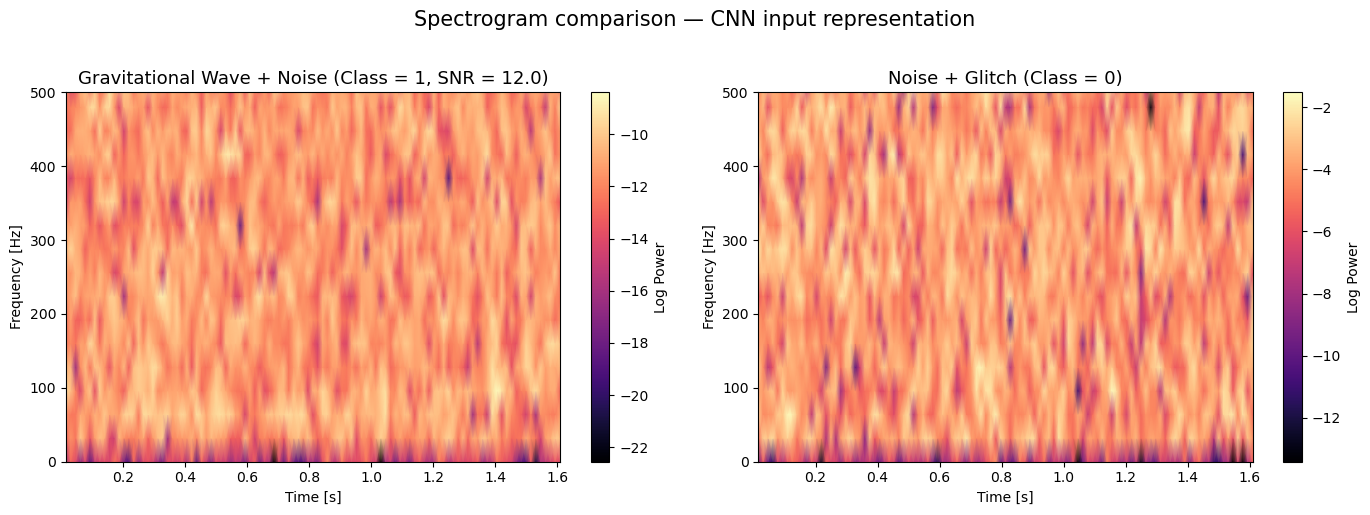

Spectrogram shape (f x t): (33, 103)


In [4]:
def get_spectrogram(data, fs=FS, p=PARAMS):
    """
    Computes the log-scaled spectrogram of the signal.
    Returns (f, t_spec, log_Sxx).
    """
    data_scaled = np.array(data) * 1e21  # rescaling to avoid numerical underflow

    f, t_s, Sxx = sp_signal.spectrogram(
        data_scaled,
        fs=fs,
        nperseg=p["nperseg"],
        noverlap=p["noverlap"]
    )

    return f, t_s, np.log(Sxx + 1e-10)


# ── Generate one example per class ───────────────────────────

snr_demo = 12.0  # set to 100 for debugging, then back to 12

# Class 1: signal + noise
t_gw, gw_data = generate_wave(target_snr=snr_demo)
f_gw, t_sg, spec_gw = get_spectrogram(gw_data)

# Class 0: noise only (with or without glitch)
n_samples_noise = len(t_gw)
t_noise = np.arange(n_samples_noise) * PARAMS["delta_t"]
_, noise_data = generate_noise(t_noise, sigma=1e-21, add_glitch=True)
f_no, t_sn, spec_no = get_spectrogram(noise_data)

# ── Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].pcolormesh(
    t_sg, f_gw, spec_gw,
    shading='gouraud',
    cmap='magma'
)

axes[0].set_title(
    f"Gravitational Wave + Noise (Class = 1, SNR = {snr_demo})",
    fontsize=13
)
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Frequency [Hz]")
axes[0].set_ylim(0, 500)
plt.colorbar(im0, ax=axes[0], label="Log Power")

im1 = axes[1].pcolormesh(
    t_sn, f_no, spec_no,
    shading='gouraud',
    cmap='magma'
)

axes[1].set_title("Noise + Glitch (Class = 0)", fontsize=13)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Frequency [Hz]")
axes[1].set_ylim(0, 500)
plt.colorbar(im1, ax=axes[1], label="Log Power")

plt.suptitle(
    "Spectrogram comparison — CNN input representation",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

print("Spectrogram shape (f x t):", spec_gw.shape)

## Block 4 — Creating the Training Dataset

In [5]:
def create_dataset(n_elements, p=PARAMS, verbose=True):
    """
    Generates n_elements labeled spectrogram samples (50% signal, 50% noise).

    All physical parameters are randomly sampled within the ranges defined in PARAMS.

    Returns:
        X_array: (N, H, W_max, 1)
        y_array: (N, 1)
    """
    if verbose:
        print(f"Generating dataset with {n_elements} samples...")

    n_noise = n_elements // 2
    n_signal = n_elements - n_noise

    X_list, y_list = [], []
    fs = FS

    # ── Class 0: Noise (with optional glitches) ───────────────
    for i in range(n_noise):
        t_rand   = random.uniform(p["window_min"], p["window_max"])
        sig_rand = random.uniform(p["sigma_min"],  p["sigma_max"])

        N_samp = int(t_rand / p["delta_t"])
        times  = np.arange(N_samp) * p["delta_t"]

        add_glitch = np.random.rand() < p["glitch_prob"]
        _, noise = generate_noise(times, sigma=sig_rand, add_glitch=add_glitch, p=p)

        _, _, spec = get_spectrogram(noise, fs=fs, p=p)
        X_list.append(np.expand_dims(spec, axis=-1))
        y_list.append(0)

        if verbose and (i + 1) % max(1, n_noise // 5) == 0:
            print(f"  Noise: {i+1}/{n_noise}")

    # ── Class 1: Signal + Noise ───────────────────────────────
    for i in range(n_signal):
        snr = random.uniform(p["snr_min"], p["snr_max"])
        d   = random.uniform(p["d_min"], p["d_max"])
        f0  = random.uniform(p["f_lower_min"], p["f_lower_max"])

        s1z = random.uniform(p["spin_min"], p["spin_max"]) if p["use_spin"] else 0.0
        s2z = random.uniform(p["spin_min"], p["spin_max"]) if p["use_spin"] else 0.0

        _, wave = generate_wave(
            distance=d,
            f_lower=f0,
            target_snr=snr,
            delta_t=p["delta_t"],
            spin1z=s1z,
            spin2z=s2z,
            use_spin=p["use_spin"],
            p=p
        )

        _, _, spec = get_spectrogram(wave, fs=fs, p=p)
        X_list.append(np.expand_dims(spec, axis=-1))
        y_list.append(1)

        if verbose and (i + 1) % max(1, n_signal // 5) == 0:
            print(f"  Signal: {i+1}/{n_signal}")

    # ── Shuffle and 2D padding ────────────────────────────────
    combined = list(zip(X_list, y_list))
    random.shuffle(combined)
    X_list, y_list = zip(*combined)

    fixed_h = X_list[0].shape[0]
    max_w   = max(s.shape[1] for s in X_list)

    if verbose:
        print(f"Spectrogram shape: height={fixed_h}, max_width={max_w}")

    X_array = np.zeros((len(X_list), fixed_h, max_w, 1), dtype='float32')

    for i, spec in enumerate(X_list):
        h, w, _ = spec.shape
        X_array[i, :h, :w, :] = spec

    y_array = np.array(y_list, dtype='float32').reshape(-1, 1)

    return X_array, y_array


# ── Create main dataset ──────────────────────────────────────
X_all, y_all = create_dataset(PARAMS["n_samples"])

# ── Train / validation / test split ──────────────────────────
test_frac = PARAMS["test_size"]
val_frac  = PARAMS["val_size"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all,
    test_size=test_frac,
    stratify=y_all,
    random_state=42
)

val_frac_adj = val_frac / (1.0 - test_frac)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_frac_adj,
    stratify=y_temp,
    random_state=42
)

# ── Normalization (train mean/std) ──────────────────────────
mean_tr = X_train.mean()
std_tr  = X_train.std() + 1e-8

X_train = (X_train - mean_tr) / std_tr
X_val   = (X_val   - mean_tr) / std_tr
X_test  = (X_test  - mean_tr) / std_tr


# ── PyTorch tensors (N, C=1, H, W) ──────────────────────────
def to_tensor(X, y):
    Xt = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2)
    yt = torch.tensor(y, dtype=torch.float32)
    return Xt, yt


X_tr_t, y_tr_t = to_tensor(X_train, y_train)
X_vl_t, y_vl_t = to_tensor(X_val, y_val)
X_te_t, y_te_t = to_tensor(X_test, y_test)

bs = PARAMS["batch_size"]

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=bs, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_vl_t, y_vl_t), batch_size=bs)
test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=bs)

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"CNN input shape: {X_tr_t.shape[1:]}")

Generating dataset with 10000 samples...
  Noise: 1000/5000
  Noise: 2000/5000
  Noise: 3000/5000
  Noise: 4000/5000
  Noise: 5000/5000
  Signal: 1000/5000
  Signal: 2000/5000
  Signal: 3000/5000
  Signal: 4000/5000
  Signal: 5000/5000
Spectrogram shape: height=33, max_width=126

Train: 7000 | Val: 1500 | Test: 1500
CNN input shape: torch.Size([1, 33, 126])


In [6]:
print("=== DIAGNOSTICS ===")
print(f"Total samples: {len(X_all)}")
print(f"Train: {len(X_train)}")
print(f"Val: {len(X_val)}")
print(f"Test: {len(X_test)}")

# Verify validation set consistency
print(f"\nFirst validation sample (index 0):")
print(f"  Shape: {X_val[0].shape}")
print(f"  Hash: {hash(X_val[0].tobytes())}")
print("\n(This hash should be identical if you rerun this cell)")

# Check class distribution
print(f"\nValidation distribution:")
print(f"  Class 0 (noise): {(y_val == 0).sum()}")
print(f"  Class 1 (signal): {(y_val == 1).sum()}")

=== DIAGNOSTICS ===
Total samples: 10000
Train: 7000
Val: 1500
Test: 1500

First validation sample (index 0):
  Shape: (33, 126, 1)
  Hash: 5978143773153292492

(This hash should be identical if you rerun this cell)

Validation distribution:
  Class 0 (noise): 750
  Class 1 (signal): 750


## Block 5 — CNN Architecture

In [7]:
class GravWaveCNN(nn.Module):
    """
    Convolutional neural network for classification of gravitational wave spectrograms.

    Architecture:
      Conv2d → BatchNorm → ReLU → MaxPool  (x3, increasing filters)
      Conv2d → BatchNorm → ReLU            (extra layer without pooling)
      AdaptiveAvgPool2d(1)                 (equivalent to Global Average Pooling)
      Linear → ReLU → Dropout
      Linear → ReLU → Dropout
      Linear → Sigmoid                     (probability of class 1)
    """

    def __init__(self, dropout1=0.5, dropout2=0.3):
        super().__init__()

        # ── Convolutional backbone ─────────────────────────────
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1,  32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4 (no pooling — preserves resolution)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        # ── Global Average Pooling → fixed 256-dim vector ──────
        self.gap = nn.AdaptiveAvgPool2d(1)

        # ── Fully connected classifier ─────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout1),

            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout2),

            nn.Linear(64, 1),
            nn.Sigmoid()            # output in [0,1] → class probability
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)


# ── Instantiate model ─────────────────────────────────────────
model = GravWaveCNN(
    dropout1=PARAMS["dropout1"],
    dropout2=PARAMS["dropout2"]
).to(device)

# Quick summary
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nTotal parameters:      {total_params:,}")
print(f"Trainable parameters:  {train_params:,}")

GravWaveCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, 

## Block 6 — Training and Evaluation Functions

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds_prob = model(X_batch)
        loss = criterion(preds_prob, y_batch)
        loss.backward()

        # ── Gradient clipping: prevents exploding gradients ──
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds_bin   = (preds_prob >= 0.5).float()
        correct    += (preds_bin == y_batch).sum().item()
        total      += y_batch.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            probs = model(X_batch)
            loss  = criterion(probs, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds_bin   = (probs >= 0.5).float()
            correct    += (preds_bin == y_batch).sum().item()
            total      += y_batch.size(0)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    return (
        total_loss / total,
        correct / total,
        np.array(all_probs).ravel(),
        np.array(all_labels).ravel()
    )


print("✅  Training functions defined (with gradient clipping).")

✅  Training functions defined (with gradient clipping).


## Block 7 — Training with Early Stopping

In [9]:
epochs = 14
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=PARAMS["lr"])  # weight decay can be added: weight_decay=1e-4
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

history = {k: [] for k in ("loss", "val_loss", "acc", "val_acc")}
best_val_loss = float('inf')
best_weights  = copy.deepcopy(model.state_dict())
patience_ctr  = 0

print(f"Training for a maximum of {epochs} epochs (patience={PARAMS['patience']})...")
print("-" * 65)

print("\nChecking that validation set is fixed...")
first_batch_val = next(iter(val_loader))
val_hash = hash(first_batch_val[0].cpu().numpy().tobytes())
print(f"Validation first-batch hash: {val_hash}")
print("(This value should be identical across notebook runs)\n")

for epoch in range(epochs):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(vl_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history["loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    marker = ""
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_weights  = copy.deepcopy(model.state_dict())
        patience_ctr  = 0
        marker = " ◀ best"
    else:
        patience_ctr += 1

    print(f"Epoch {epoch+1:3d} | "
          f"loss={tr_loss:.4f}  acc={tr_acc:.4f} | "
          f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f} | "
          f"lr={current_lr:.2e}{marker}")

    if patience_ctr >= PARAMS["patience"]:
        print(f"\nEarly stopping at epoch {epoch+1}.")
        break

model.load_state_dict(best_weights)

te_loss, te_acc, te_probs, te_labels = evaluate(model, test_loader, criterion, device)
print(f"\n{'='*65}")
print(f"  ✅  TEST accuracy: {te_acc*100:.2f}%")
print(f"{'='*65}")

Training for a maximum of 14 epochs (patience=10)...
-----------------------------------------------------------------

Checking that validation set is fixed...
Validation first-batch hash: 8716668885093284858
(This value should be identical across notebook runs)

Epoch   1 | loss=0.6205  acc=0.7104 | val_loss=0.5748  val_acc=0.7147 | lr=5.00e-05 ◀ best
Epoch   2 | loss=0.5571  acc=0.7281 | val_loss=0.5252  val_acc=0.7313 | lr=5.00e-05 ◀ best
Epoch   3 | loss=0.5226  acc=0.7389 | val_loss=0.5004  val_acc=0.7300 | lr=5.00e-05 ◀ best
Epoch   4 | loss=0.4943  acc=0.7580 | val_loss=0.4784  val_acc=0.7420 | lr=5.00e-05 ◀ best
Epoch   5 | loss=0.4773  acc=0.7579 | val_loss=0.4580  val_acc=0.7527 | lr=5.00e-05 ◀ best
Epoch   6 | loss=0.4690  acc=0.7631 | val_loss=0.4497  val_acc=0.7620 | lr=5.00e-05 ◀ best
Epoch   7 | loss=0.4518  acc=0.7710 | val_loss=0.4379  val_acc=0.7767 | lr=5.00e-05 ◀ best
Epoch   8 | loss=0.4400  acc=0.7767 | val_loss=0.4223  val_acc=0.7840 | lr=5.00e-05 ◀ best
Epoch  

## Block 8 — Learning Curves

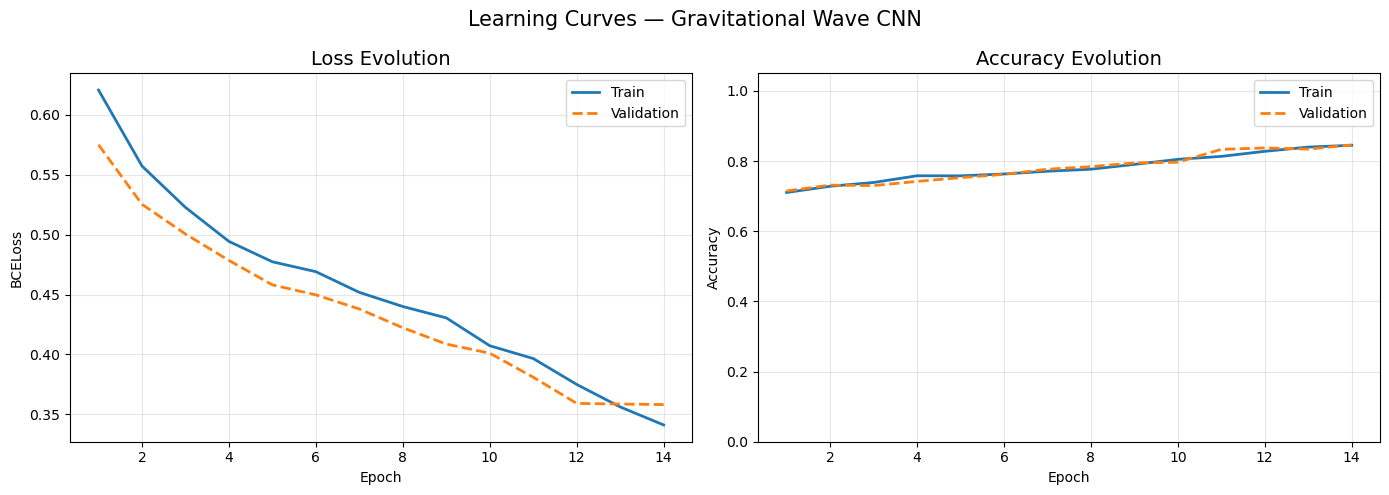

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep_range = range(1, len(history["loss"]) + 1)

axes[0].plot(ep_range, history["loss"],     label="Train", lw=2)
axes[0].plot(ep_range, history["val_loss"], label="Validation", lw=2, linestyle='--')
axes[0].set_title("Loss Evolution", fontsize=14)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCELoss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, history["acc"],     label="Train", lw=2)
axes[1].plot(ep_range, history["val_acc"], label="Validation", lw=2, linestyle='--')
axes[1].set_title("Accuracy Evolution", fontsize=14)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Learning Curves — Gravitational Wave CNN", fontsize=15)
plt.tight_layout()
plt.show()

## Block 9 — Evaluation: ROC and Confusion Matrix

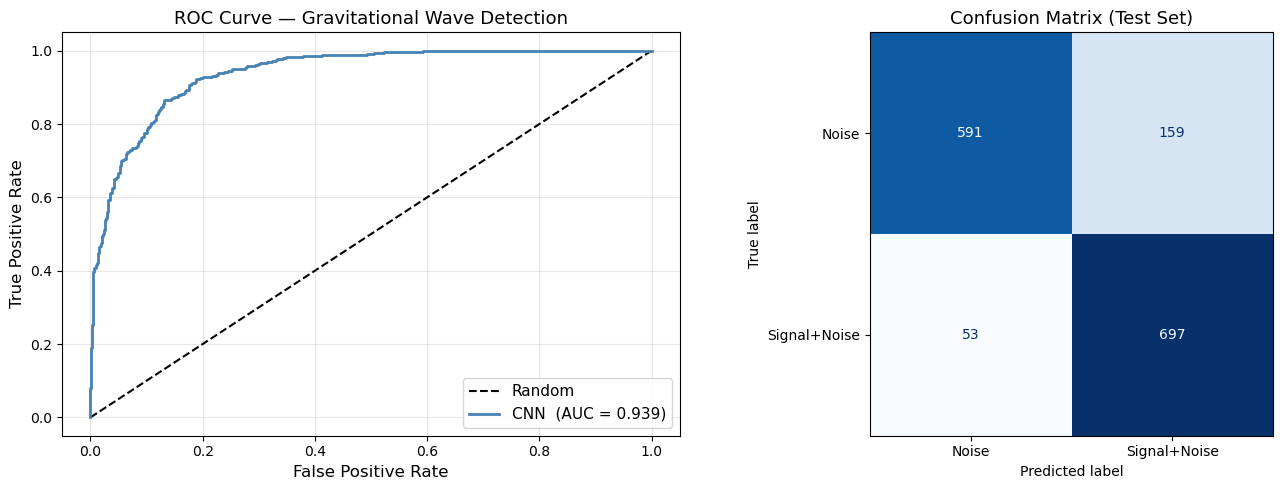


--- DETAILED CLASSIFICATION REPORT (Test Set) ---
                  precision    recall  f1-score   support

       Noise (0)       0.92      0.79      0.85       750
Signal+Noise (1)       0.81      0.93      0.87       750

        accuracy                           0.86      1500
       macro avg       0.87      0.86      0.86      1500
    weighted avg       0.87      0.86      0.86      1500



In [11]:
# ── ROC ──────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(te_labels, te_probs)
auc_score   = auc(fpr, tpr)

# ── Confusion Matrix ──────────────────────────────────────────
y_pred_bin = (te_probs >= 0.5).astype(int)
cm = confusion_matrix(te_labels.astype(int), y_pred_bin)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'CNN  (AUC = {auc_score:.3f})')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — Gravitational Wave Detection', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Confusion Matrix
disp = ConfusionMatrixDisplay(cm, display_labels=["Noise", "Signal+Noise"])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix (Test Set)', fontsize=13)

plt.tight_layout()
plt.show()

# Detailed report
print("\n--- DETAILED CLASSIFICATION REPORT (Test Set) ---")
print(classification_report(
    te_labels.astype(int), y_pred_bin,
    target_names=["Noise (0)", "Signal+Noise (1)"]
))

## Block 10 — Sensitivity vs. SNR

Calibrating background noise independently...

Evaluating Accuracy across SNR levels...
  SNR =   1.0 → Accuracy = 49.0%
  SNR =   2.0 → Accuracy = 50.0%
  SNR =   4.0 → Accuracy = 51.0%
  SNR =   6.0 → Accuracy = 62.0%
  SNR =   8.0 → Accuracy = 67.0%
  SNR =  10.0 → Accuracy = 63.0%
  SNR =  15.0 → Accuracy = 79.0%
  SNR =  20.0 → Accuracy = 83.0%
  SNR =  30.0 → Accuracy = 81.0%
  SNR =  50.0 → Accuracy = 76.0%
  SNR = 100.0 → Accuracy = 74.0%


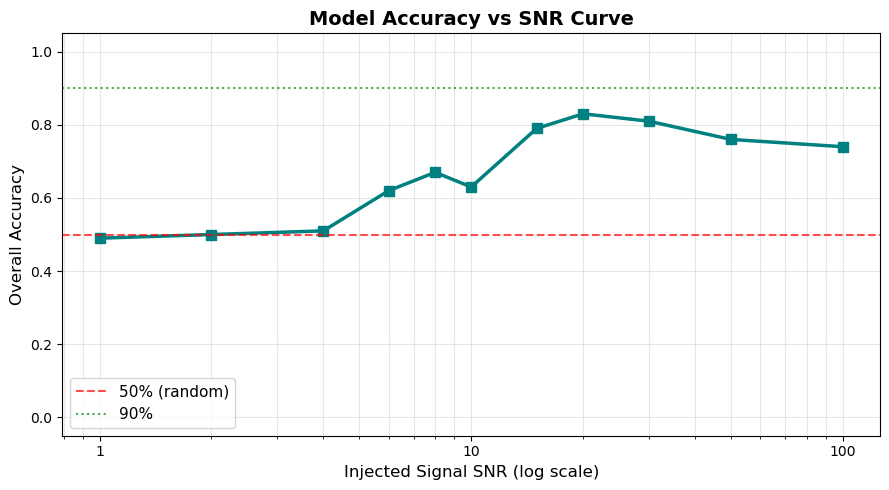

In [12]:
## Block 10 — Accuracy vs SNR

def get_dynamic_noise_calibration(n_samples=200, p=PARAMS):
    """
    Generates pure noise to estimate the mean and standard deviation of the background.
    This ensures the evaluation is fully independent from training.
    """
    noise_pixels = []
    fs = FS

    for _ in range(n_samples):
        t_rand   = random.uniform(p["window_min"], p["window_max"])
        sig_rand = random.uniform(p["sigma_min"],  p["sigma_max"])
        times    = np.arange(int(t_rand / p["delta_t"])) * p["delta_t"]
        add_gl   = np.random.rand() < p["glitch_prob"]

        _, pure_noise = generate_noise(times, sigma=sig_rand, add_glitch=add_gl, p=p)
        _, _, spec = get_spectrogram(pure_noise, fs=fs, p=p)
        noise_pixels.append(spec.flatten())

    concat_noise = np.concatenate(noise_pixels)
    return float(np.mean(concat_noise)), float(np.std(concat_noise))

print("Calibrating background noise independently...")
dyn_mean, dyn_std = get_dynamic_noise_calibration()


def evaluate_accuracy_at_snr(model, snr_target, baseline_mean, baseline_std,
                             n_samples=100, p=PARAMS):
    """
    Evaluates model accuracy at a fixed SNR.
    Generates a balanced batch: 50% pure noise (Class 0) and 50% signal+noise (Class 1).
    """
    X_list = []
    y_list = []
    fs = FS

    n_noise = n_samples // 2
    n_signal = n_samples - n_noise

    # ── 1. Generate Class 0 samples (Pure Noise) ──
    for _ in range(n_noise):
        t_rand   = random.uniform(p["window_min"], p["window_max"])
        sig_rand = random.uniform(p["sigma_min"],  p["sigma_max"])
        times    = np.arange(int(t_rand / p["delta_t"])) * p["delta_t"]
        add_gl   = np.random.rand() < p["glitch_prob"]

        _, noise = generate_noise(times, sigma=sig_rand, add_glitch=add_gl, p=p)
        _, _, spec = get_spectrogram(noise, fs=fs, p=p)
        X_list.append(np.expand_dims(spec, axis=-1))
        y_list.append(0)  # Label: Noise

    # ── 2. Generate Class 1 samples (Signal + Noise at fixed SNR) ──
    for _ in range(n_signal):
        _, wave = generate_wave(target_snr=snr_target, p=p)
        _, _, spec = get_spectrogram(wave, fs=fs, p=p)
        X_list.append(np.expand_dims(spec, axis=-1))
        y_list.append(1)  # Label: Signal

    # Padding to match tensor dimensions
    max_w   = max(s.shape[1] for s in X_list)
    fixed_h = X_list[0].shape[0]
    X_batch = np.zeros((n_samples, fixed_h, max_w, 1), dtype='float32')

    for i, s in enumerate(X_list):
        X_batch[i, :s.shape[0], :s.shape[1], :] = s

    # ── 3. Normalize using independent calibration ──
    X_batch = (X_batch - baseline_mean) / (baseline_std + 1e-10)

    # Convert to tensors and move to device
    X_t = torch.tensor(X_batch, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
    y_t = torch.tensor(y_list, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        probs = model(X_t).ravel()
        preds = (probs >= 0.5).float()

    correct = (preds == y_t).sum().item()
    accuracy = correct / n_samples

    return accuracy


snr_levels = [1, 2, 4, 6, 8, 10, 15, 20, 30, 50, 100]
print("\nEvaluating Accuracy across SNR levels...")
acc_list = []

for snr in snr_levels:
    acc = evaluate_accuracy_at_snr(model, snr, dyn_mean, dyn_std, n_samples=100)
    acc_list.append(acc)
    print(f"  SNR = {snr:5.1f} → Accuracy = {acc*100:.1f}%")

# ── Plot ─────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(snr_levels, acc_list, marker='s', lw=2.5, color='teal', markersize=7)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50% (random)')
plt.axhline(0.9, color='green', linestyle=':', alpha=0.7, label='90%')
plt.xscale('log')
plt.gca().xaxis.set_major_formatter(mticker.ScalarFormatter())
plt.ylim(-0.05, 1.05)
plt.xlabel('Injected Signal SNR (log scale)', fontsize=12)
plt.ylabel('Overall Accuracy', fontsize=12)
plt.title('Model Accuracy vs SNR Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Block 11 — Saving and Loading the Model

In [13]:
MODEL_PATH = "grav_wave_cnn6.pt"

# ─────────────────────────────────────────────
# Detect Colab environment
# ─────────────────────────────────────────────
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ─────────────────────────────────────────────
# 1. SAVE MODEL (both environments)
# ─────────────────────────────────────────────
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'params': PARAMS,
}, MODEL_PATH)

print(f"✅ Model saved at: {MODEL_PATH}")

# ─────────────────────────────────────────────
# 2. COLAB-SPECIFIC ACTIONS
# ─────────────────────────────────────────────
if IN_COLAB:
    print("⬇️ Downloading model to your PC...")
    files.download(MODEL_PATH)

    # (optional) upload file from local PC
    uploaded = files.upload()
    uploaded_filename = list(uploaded.keys())[0]

    checkpoint = torch.load(
        uploaded_filename,
        map_location=device,
        weights_only=False
    )

else:
    # ─────────────────────────────────────────────
    # 3. LOCAL ENV (VS CODE)
    # ─────────────────────────────────────────────
    print("📂 Local environment (VS Code): loading model from saved file")
    checkpoint = torch.load(
        MODEL_PATH,
        map_location=device,
        weights_only=False
    )

# ─────────────────────────────────────────────
# 4. REBUILD MODEL (common)
# ─────────────────────────────────────────────
model_loaded = GravWaveCNN(
    dropout1=checkpoint['params']['dropout1'],
    dropout2=checkpoint['params']['dropout2']
).to(device)

model_loaded.load_state_dict(checkpoint['model_state_dict'])
model_loaded.eval()

print("✅ Model loaded and ready for inference.")

✅ Model saved at: grav_wave_cnn6.pt
📂 Local environment (VS Code): loading model from saved file
✅ Model loaded and ready for inference.


## Block 12 — Test Dataset with Random Parameters

Generate a completely new evaluation dataset with random values for **spin**,
**SNR**, **mass**, **distance**, and **mixed polarization** (h+ and hx) to measure generalization.

Generating generalization dataset (200 samples)...

Generalization accuracy (spin + polarization): 84.50%


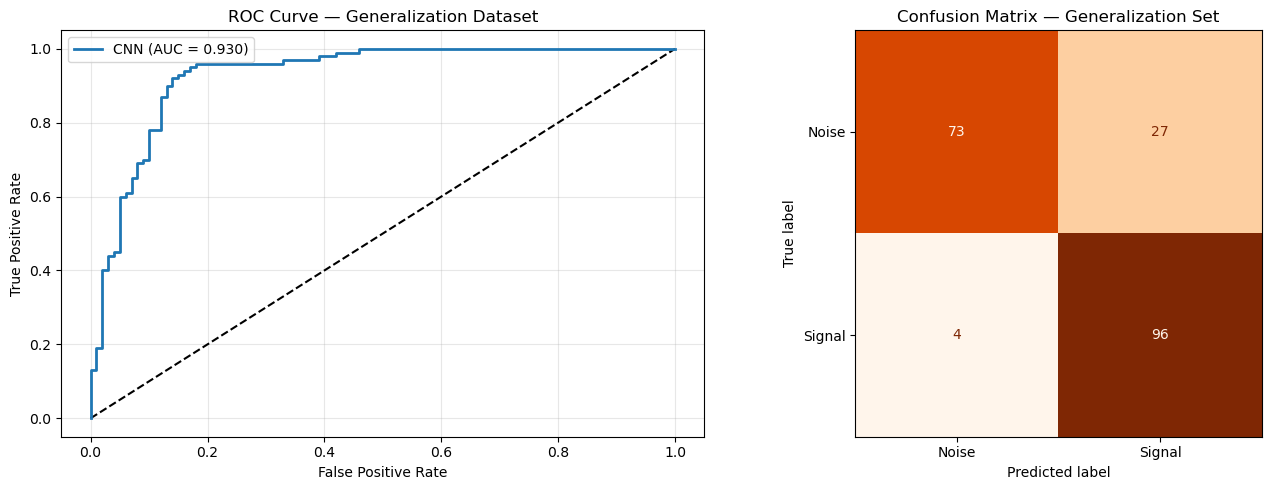


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

   Noise (0)       0.95      0.73      0.82       100
  Signal (1)       0.78      0.96      0.86       100

    accuracy                           0.84       200
   macro avg       0.86      0.84      0.84       200
weighted avg       0.86      0.84      0.84       200



In [14]:
NEW_PARAMS = {
    **PARAMS,  # inherit base configuration

    # ── Modified ranges for robustness testing ───────────────
    "snr_min": 3.0,      # lower SNR → harder detection regime
    "snr_max": 25.0,

    "spin_min": -0.95,   # extended spin range
    "spin_max":  0.95,

    "d_min": 50.0,       # extreme distance range
    "d_max": 1500.0,

    "use_spin": True,
}


def create_spin_test_dataset(n_elements, p=NEW_PARAMS, verbose=True):
    """
    Generates a generalization dataset including:
    - random spins
    - polarization mixing
    - varied distances and SNR

    This dataset is NOT used for training.
    It is designed to evaluate out-of-distribution performance.
    """

    if verbose:
        print(f"Generating generalization dataset ({n_elements} samples)...")

    n_noise = n_elements // 2
    n_signal = n_elements - n_noise

    X_data, y_data = [], []
    fs = FS

    # ─────────────────────────────────────────────
    # Class 0: noise (with optional glitches)
    # ─────────────────────────────────────────────
    for _ in range(n_noise):
        duration = random.uniform(p["window_min"], p["window_max"])
        sigma    = random.uniform(p["sigma_min"], p["sigma_max"])

        N = int(duration / p["delta_t"])
        t = np.arange(N) * p["delta_t"]

        _, noise = generate_noise(
            t,
            sigma=sigma,
            add_glitch=(np.random.rand() < p["glitch_prob"]),
            p=p
        )

        _, _, spec = get_spectrogram(noise, fs=fs, p=p)
        X_data.append(np.expand_dims(spec, -1))
        y_data.append(0)

    # ─────────────────────────────────────────────
    # Class 1: gravitational wave signals
    # ─────────────────────────────────────────────
    for _ in range(n_signal):
        snr = random.uniform(p["snr_min"], p["snr_max"])
        d   = random.uniform(p["d_min"], p["d_max"])
        f0  = random.uniform(p["f_lower_min"], p["f_lower_max"])

        spin1 = random.uniform(p["spin_min"], p["spin_max"])
        spin2 = random.uniform(p["spin_min"], p["spin_max"])

        use_pol_mix = (np.random.rand() < 0.5)

        _, wave = generate_wave(
            distance=d,
            f_lower=f0,
            target_snr=snr,
            delta_t=p["delta_t"],
            spin1z=spin1,
            spin2z=spin2,
            use_spin=True,
            polarization_mix=use_pol_mix,
            p=p
        )

        _, _, spec = get_spectrogram(wave, fs=fs, p=p)
        X_data.append(np.expand_dims(spec, -1))
        y_data.append(1)

    # ─────────────────────────────────────────────
    # Padding to uniform spectrogram size
    # ─────────────────────────────────────────────
    max_w = max(s.shape[1] for s in X_data)
    h     = X_data[0].shape[0]

    X_array = np.zeros((len(X_data), h, max_w, 1), dtype=np.float32)

    for i, s in enumerate(X_data):
        X_array[i, :s.shape[0], :s.shape[1], :] = s

    y_array = np.array(y_data, dtype=np.float32).reshape(-1, 1)

    return X_array, y_array


# ─────────────────────────────────────────────
# Dataset generation
# ─────────────────────────────────────────────
N_GEN = 200

X_gen, y_gen = create_spin_test_dataset(N_GEN)

# Normalize using training statistics
X_gen = (X_gen - mean_tr) / (std_tr + 1e-10)

# PyTorch conversion
X_gen_t = torch.tensor(X_gen, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
y_gen_t = torch.tensor(y_gen, dtype=torch.float32)

gen_loader = DataLoader(
    TensorDataset(X_gen_t, y_gen_t),
    batch_size=PARAMS["batch_size"]
)

_, gen_acc, gen_probs, gen_labels = evaluate(model, gen_loader, criterion, device)

print(f"\nGeneralization accuracy (spin + polarization): {gen_acc * 100:.2f}%")

# ─────────────────────────────────────────────
# Evaluation metrics
# ─────────────────────────────────────────────
y_pred = (gen_probs >= 0.5).astype(int)

cm = confusion_matrix(gen_labels.astype(int), y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
fpr, tpr, _ = roc_curve(gen_labels, gen_probs)
auc_score = auc(fpr, tpr)

axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].plot(fpr, tpr, lw=2, label=f'CNN (AUC = {auc_score:.3f})')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Generalization Dataset")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confusion matrix
ConfusionMatrixDisplay(cm, display_labels=["Noise", "Signal"]).plot(
    ax=axes[1],
    cmap='Oranges',
    colorbar=False
)

axes[1].set_title("Confusion Matrix — Generalization Set")

plt.tight_layout()
plt.show()

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(
    gen_labels.astype(int),
    y_pred,
    target_names=["Noise (0)", "Signal (1)"]
))

## Block 13 — Generalization Test with New Morphologies

We evaluate signals **not seen during training**: linear and quadratic chirps.

Linear chirp    → P(signal) = 0.0000  ✗ Not detected
Quadratic chirp → P(signal) = 0.0000  ✗ Not detected


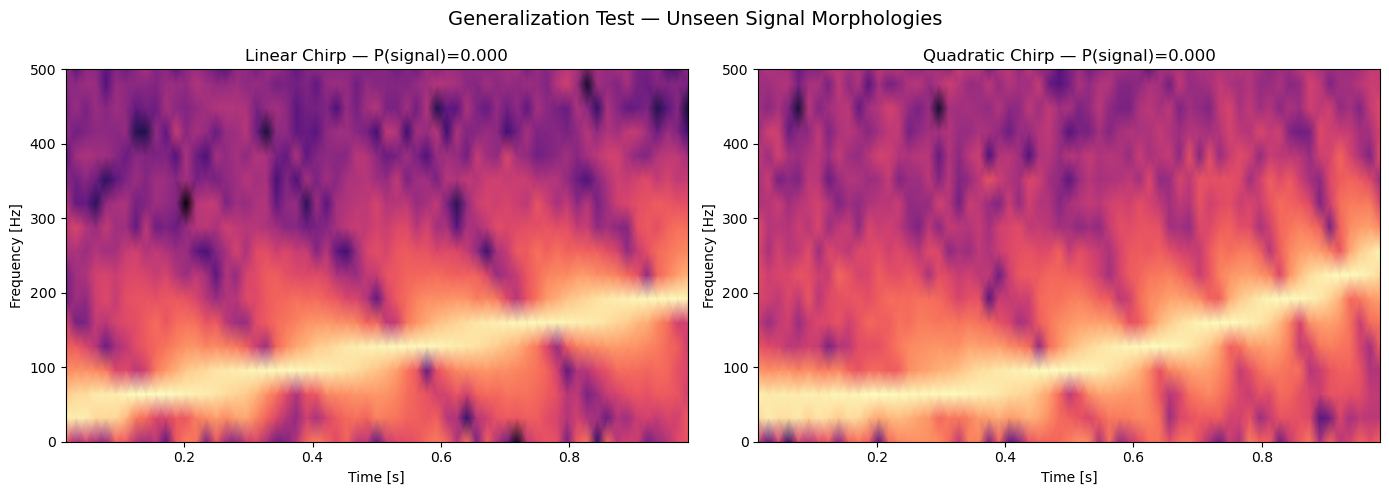

In [15]:
def predict_single(data, model, mean, std, device, p=PARAMS):
    """
    Computes the probability that a 1D time series contains a gravitational wave signal.

    Steps:
    - Convert to spectrogram
    - Normalize using training statistics
    - Run CNN inference
    """
    _, _, spec = get_spectrogram(data, fs=FS, p=p)

    X = np.expand_dims(spec, axis=(0, -1)).astype(np.float32)
    X = (X - mean) / (std + 1e-10)

    Xt = torch.tensor(X).permute(0, 3, 1, 2).to(device)

    model.eval()
    with torch.no_grad():
        return model(Xt).item()


# ─────────────────────────────────────────────
# Synthetic test signals (unseen morphologies)
# ─────────────────────────────────────────────
t = np.linspace(0, 1, FS)

# Linear chirp
sig_linear = sp_signal.chirp(t, f0=40, f1=200, t1=1, method='linear')
sig_linear /= (np.std(sig_linear) + 1e-8)

_, noise_a = generate_noise(t, sigma=1e-21)
data_linear = noise_a + 12e-21 * sig_linear

# Quadratic chirp
sig_quad = sp_signal.chirp(t, f0=50, f1=250, t1=1, method='quadratic')
sig_quad /= (np.std(sig_quad) + 1e-8)

_, noise_b = generate_noise(t, sigma=1e-21)
data_quad = noise_b + 12e-21 * sig_quad


# ─────────────────────────────────────────────
# Model predictions
# ─────────────────────────────────────────────
p_linear = predict_single(data_linear, model, mean_tr, std_tr, device)
p_quad   = predict_single(data_quad, model, mean_tr, std_tr, device)

print(f"Linear chirp    → P(signal) = {p_linear:.4f}  "
      f"{'✓ Detected' if p_linear > 0.5 else '✗ Not detected'}")

print(f"Quadratic chirp → P(signal) = {p_quad:.4f}  "
      f"{'✓ Detected' if p_quad > 0.5 else '✗ Not detected'}")


# ─────────────────────────────────────────────
# Spectrogram visualization
# ─────────────────────────────────────────────
_, t_lin, spec_lin = get_spectrogram(data_linear)
_, t_q, spec_quad  = get_spectrogram(data_quad)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pcolormesh(
    t_lin,
    np.linspace(0, FS // 2, spec_lin.shape[0]),
    spec_lin,
    shading='gouraud',
    cmap='magma'
)
axes[0].set_title(f'Linear Chirp — P(signal)={p_linear:.3f}')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_ylim(0, 500)

axes[1].pcolormesh(
    t_q,
    np.linspace(0, FS // 2, spec_quad.shape[0]),
    spec_quad,
    shading='gouraud',
    cmap='magma'
)
axes[1].set_title(f'Quadratic Chirp — P(signal)={p_quad:.3f}')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_ylim(0, 500)

plt.suptitle(
    'Generalization Test — Unseen Signal Morphologies',
    fontsize=14
)

plt.tight_layout()
plt.show()

## Block 14-A — Comparison with Matched Filtering (Ideal Case for MF)

Calibrating CNN background noise statistics...

🔬 BLOCK 14-A — MATCHED FILTERING DOMINATES (ACCURACY VS SNR)
Matched-filter threshold (99th percentile): 0.0000

SNR  | MF Acc. | CNN Acc.
------------------------------
 1.0 |  100.0% |   50.0%
 2.0 |  100.0% |   50.0%
 3.0 |   99.0% |   50.0%
 4.0 |  100.0% |   50.0%
 6.0 |  100.0% |   50.0%
 8.0 |   99.0% |   50.0%
10.0 |  100.0% |   50.0%
15.0 |  100.0% |   50.0%
20.0 |  100.0% |   50.0%
30.0 |  100.0% |   50.0%
50.0 |  100.0% |   50.0%
100.0 |  100.0% |   50.0%


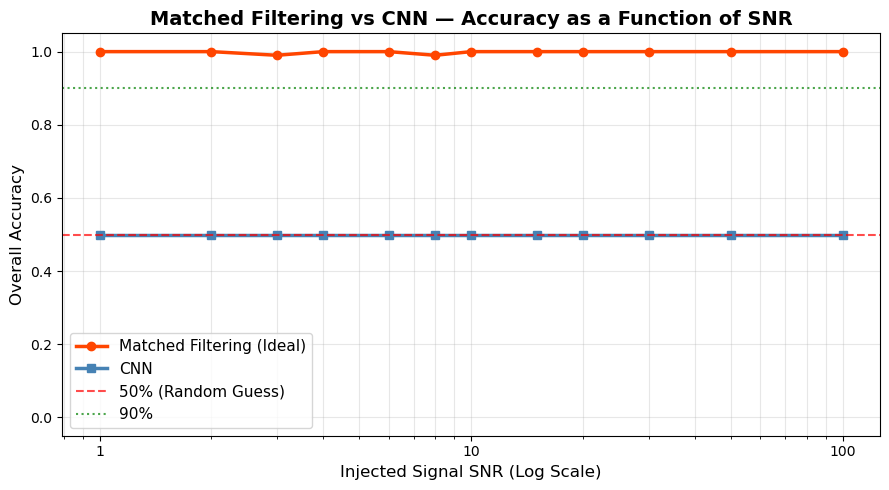

In [16]:
"""
A strictly fair comparison between CNNs and matched filtering is not possible because
both methods rely on different assumptions.

Matched filtering is statistically optimal only when the signal template is exact and
the detector noise model is perfectly known. In contrast, a CNN learns directly from
data and its performance depends on the training distribution.

Therefore, Block 14 is not intended to establish a perfectly fair benchmark, but to
illustrate the behavior of both approaches under two complementary scenarios:

1. An ideal regime where matched filtering is theoretically optimal.
2. A more realistic regime with non-ideal noise, glitches, and waveform variability,
   highlighting the robustness of deep learning methods.
"""

# ============================================================
# 🔬 BLOCK 14-A — MATCHED FILTERING DOMINATES (IDEAL SCENARIO)
# ============================================================

fs = FS
N_target = int(fs * PARAMS["window_max"])


# ------------------------------------------------------------
# 0. Independent CNN Noise Calibration
# ------------------------------------------------------------
def get_dynamic_noise_calibration_b14(n_samples=200, p=PARAMS):
    """
    Estimate the mean and standard deviation of background spectrogram pixels
    using pure noise realizations.
    """
    noise_pixels = []

    for _ in range(n_samples):
        duration = random.uniform(p["window_min"], p["window_max"])
        sigma = random.uniform(p["sigma_min"], p["sigma_max"])
        times = np.arange(int(duration / p["delta_t"])) * p["delta_t"]

        _, noise = generate_noise(times, sigma=sigma, add_glitch=False, p=p)
        _, _, spec = get_spectrogram(noise, fs=FS, p=p)

        noise_pixels.append(spec.ravel())

    noise_pixels = np.concatenate(noise_pixels)

    return float(np.mean(noise_pixels)), float(np.std(noise_pixels))


print("Calibrating CNN background noise statistics...")
dyn_mean, dyn_std = get_dynamic_noise_calibration_b14()


def cnn_predict_timeseries(x, model, baseline_mean, baseline_std, device):
    """
    Predict the probability of a gravitational-wave signal from a time series
    using independent normalization and safe spectrogram padding.
    """
    _, _, spec = get_spectrogram(x, fs=FS, p=PARAMS)

    height = X_tr_t.shape[2]
    width = X_tr_t.shape[3]

    X_pad = np.zeros((1, height, width, 1), dtype=np.float32)

    h = min(spec.shape[0], height)
    w = min(spec.shape[1], width)

    X_pad[0, :h, :w, 0] = spec[:h, :w]
    X_pad = (X_pad - baseline_mean) / (baseline_std + 1e-10)

    X_tensor = torch.tensor(X_pad).permute(0, 3, 1, 2).to(device)

    model.eval()
    with torch.no_grad():
        probability = model(X_tensor).item()

    return probability


# ------------------------------------------------------------
# 1. Fixed Template and Data Generation
# ------------------------------------------------------------
def get_fixed_waveform():
    """
    Generate the exact waveform template (m1=30 Msun, m2=25 Msun) used by
    matched filtering under ideal conditions.
    """
    hp, _ = get_td_waveform(
        approximant="IMRPhenomD",
        mass1=30,
        mass2=25,
        distance=500,
        delta_t=1 / fs,
        f_lower=20,
    )

    waveform = np.array(hp)[np.array(hp.sample_times) <= 0.0]

    if len(waveform) > N_target:
        waveform = waveform[-N_target:]

    return waveform


h_template = get_fixed_waveform()


def generate_ideal_signal(snr_target, p=PARAMS):
    """
    Generate an ideal signal following the same physics used in Block 10.

    The waveform remains fixed while the noise level is adjusted to obtain
    the desired signal-to-noise ratio (SNR).
    """
    signal = get_fixed_waveform()

    if snr_target == 0:
        sigma = p["sigma_max"]
    else:
        signal_energy = np.sqrt(np.sum(signal**2))
        sigma = signal_energy / snr_target

    times = np.arange(N_target) * p["delta_t"]

    _, noise = generate_noise(times, sigma=sigma, add_glitch=False, p=p)

    x = noise.copy()

    if snr_target > 0:
        start = N_target - len(signal)
        x[start:] += signal

    return x


def mf_optimal(x, h):
    """
    Compute the matched-filter detection statistic using normalized
    cross-correlation.

    Under white Gaussian noise, this detector is mathematically optimal.
    """
    x_norm = (x - np.mean(x)) / (np.std(x) + 1e-12)
    h_norm = (h - np.mean(h)) / (np.std(h) + 1e-12)

    correlation = np.correlate(x_norm, h_norm, mode="full")

    return np.max(correlation) / np.sqrt(len(h))

print("\n" + "=" * 60)
print("🔬 BLOCK 14-A — MATCHED FILTERING DOMINATES (ACCURACY VS SNR)")
print("=" * 60)

# ------------------------------------------------------------
# Estimate the matched-filter detection threshold
# ------------------------------------------------------------
noise_statistics = [
    mf_optimal(generate_ideal_signal(0), h_template)
    for _ in range(300)
]

threshold = np.percentile(noise_statistics, 99)

print(f"Matched-filter threshold (99th percentile): {threshold:.4f}")

snrs = [1, 2, 3, 4, 6, 8, 10, 15, 20, 30, 50, 100]

mf_accuracy = []
cnn_accuracy = []

print("\nSNR  | MF Acc. | CNN Acc.")
print("-" * 30)

n_samples_per_class = 50

for snr in snrs:

    correct_mf = 0
    correct_cnn = 0

    # --------------------------------------------------------
    # Class 0: Noise only
    # --------------------------------------------------------
    for _ in range(n_samples_per_class):

        x = generate_ideal_signal(0)

        if mf_optimal(x, h_template) <= threshold:
            correct_mf += 1

        if cnn_predict_timeseries(x, model, dyn_mean, dyn_std, device) <= 0.5:
            correct_cnn += 1

    # --------------------------------------------------------
    # Class 1: Signal + Noise
    # --------------------------------------------------------
    for _ in range(n_samples_per_class):

        x = generate_ideal_signal(snr)

        if mf_optimal(x, h_template) > threshold:
            correct_mf += 1

        if cnn_predict_timeseries(x, model, dyn_mean, dyn_std, device) > 0.5:
            correct_cnn += 1

    mf_score = correct_mf / (2 * n_samples_per_class)
    cnn_score = correct_cnn / (2 * n_samples_per_class)

    mf_accuracy.append(mf_score)
    cnn_accuracy.append(cnn_score)

    print(f"{snr:4.1f} | {100 * mf_score:6.1f}% | {100 * cnn_score:6.1f}%")


# ============================================================
# Accuracy vs SNR
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    snrs,
    mf_accuracy,
    marker="o",
    lw=2.5,
    color="orangered",
    label="Matched Filtering (Ideal)",
)

plt.plot(
    snrs,
    cnn_accuracy,
    marker="s",
    lw=2.5,
    color="steelblue",
    label="CNN",
)

plt.axhline(
    0.5,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="50% (Random Guess)",
)

plt.axhline(
    0.9,
    color="green",
    linestyle=":",
    alpha=0.7,
    label="90%",
)

plt.xscale("log")
plt.gca().xaxis.set_major_formatter(mticker.ScalarFormatter())

plt.ylim(-0.05, 1.05)

plt.xlabel("Injected Signal SNR (Log Scale)", fontsize=12)
plt.ylabel("Overall Accuracy", fontsize=12)

plt.title(
    "Matched Filtering vs CNN — Accuracy as a Function of SNR",
    fontsize=14,
    fontweight="bold",
)

plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Block 14-B — Comparison with Matched Filtering (Ideal Case for CNN)

Calibrating CNN background noise statistics...

🔬 BLOCK 14-B — CNN DOMINATES (ACCURACY VS SNR)
Matched-filter threshold (99th percentile): 0.0000

SNR  | MF Acc. | CNN Acc.
------------------------------
 1.0 |   47.0% |   50.0%
 2.0 |   49.0% |   50.0%
 3.0 |   50.0% |   52.0%
 4.0 |   50.0% |   51.0%
 6.0 |   50.0% |   52.0%
 8.0 |   47.0% |   55.0%
10.0 |   50.0% |   55.0%
15.0 |   50.0% |   54.0%
20.0 |   50.0% |   62.0%
30.0 |   50.0% |   63.0%
50.0 |   50.0% |   67.0%
100.0 |   50.0% |   59.0%


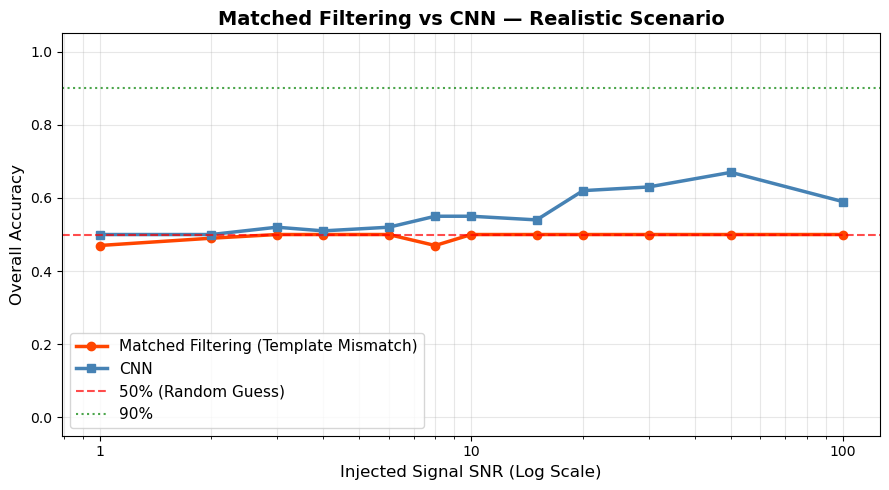

In [17]:
"""
This block simulates a more realistic detection scenario in which the signal
may deviate from the ideal waveform model and the detector noise contains
non-Gaussian artifacts (instrumental glitches).

Unlike Block 14-A, matched filtering is no longer guaranteed to be optimal,
allowing the robustness of the CNN to be evaluated under more realistic
conditions.

Performance is measured using overall classification accuracy.
"""

fs = FS
N_target = int(PARAMS["window_max"] / PARAMS["delta_t"])


# ------------------------------------------------------------
# 0. Independent CNN Noise Calibration
# ------------------------------------------------------------
def get_dynamic_noise_calibration_b14(n_samples=200, p=PARAMS):
    """
    Estimate the mean and standard deviation of background spectrogram pixels
    using realistic noise realizations with instrumental glitches.
    """
    noise_pixels = []

    for _ in range(n_samples):
        duration = random.uniform(p["window_min"], p["window_max"])
        sigma = random.uniform(p["sigma_min"], p["sigma_max"])

        times = np.arange(int(duration / p["delta_t"])) * p["delta_t"]
        add_glitch = np.random.rand() < p["glitch_prob"]

        _, noise = generate_noise(
            times,
            sigma=sigma,
            add_glitch=add_glitch,
            p=p,
        )

        _, _, spec = get_spectrogram(noise, fs=FS, p=p)

        noise_pixels.append(spec.ravel())

    noise_pixels = np.concatenate(noise_pixels)

    return float(np.mean(noise_pixels)), float(np.std(noise_pixels))


print("Calibrating CNN background noise statistics...")
dyn_mean, dyn_std = get_dynamic_noise_calibration_b14()


def cnn_predict_timeseries(x, model, baseline_mean, baseline_std, device):
    """
    Predict the probability of a gravitational-wave signal from a time series
    using independent normalization and safe spectrogram padding.
    """
    _, _, spec = get_spectrogram(x, fs=FS, p=PARAMS)

    height = X_tr_t.shape[2]
    width = X_tr_t.shape[3]

    X_pad = np.zeros((1, height, width, 1), dtype=np.float32)

    h = min(spec.shape[0], height)
    w = min(spec.shape[1], width)

    X_pad[0, :h, :w, 0] = spec[:h, :w]
    X_pad = (X_pad - baseline_mean) / (baseline_std + 1e-10)

    X_tensor = torch.tensor(X_pad).permute(0, 3, 1, 2).to(device)

    model.eval()
    with torch.no_grad():
        probability = model(X_tensor).item()

    return probability


def noise_glitch():
    """
    Generate a realistic noise realization including instrumental glitches.
    """
    _, x = generate_wave(target_snr=0, p=PARAMS)

    if len(x) < N_target:
        x = np.pad(x, (0, N_target - len(x)))
    else:
        x = x[:N_target]

    if np.random.rand() < PARAMS["glitch_prob"]:
        t = np.arange(N_target) * PARAMS["delta_t"]
        x += generate_glitch(t, sigma=np.std(x), p=PARAMS)

    return x


def mf_simple(x, h):
    """
    Simplified matched-filter implementation based on FFT correlation.

    This detector intentionally assumes an imperfect waveform model,
    making it less robust than the ideal matched filter used in Block 14-A.
    """
    x = x[:N_target]
    h = h[:N_target]

    x = (x - np.mean(x)) / (np.std(x) + 1e-12)
    h = (h - np.mean(h)) / (np.std(h) + 1e-12)

    X = np.fft.rfft(x)
    H = np.fft.rfft(h)

    correlation = np.real(np.fft.irfft(X * np.conj(H)))

    return np.max(correlation)

def generate_template():
    """
    Generate an approximate waveform template used by the matched filter
    in the realistic scenario.
    """
    hp, _ = get_td_waveform(
        approximant="IMRPhenomD",
        mass1=28,          # Slightly different masses
        mass2=23,
        distance=500,
        delta_t=1 / FS,
        f_lower=20,
    )

    template = np.array(hp)[np.array(hp.sample_times) <= 0.0]

    if len(template) > N_target:
        template = template[-N_target:]

    return template

print("\n" + "=" * 60)
print("🔬 BLOCK 14-B — CNN DOMINATES (ACCURACY VS SNR)")
print("=" * 60)

# ------------------------------------------------------------
# Prepare the template and estimate the matched-filter threshold
# ------------------------------------------------------------
template = generate_template()

if len(template) < N_target:
    template = np.pad(template, (0, N_target - len(template)))
else:
    template = template[:N_target]

noise_statistics = [
    mf_simple(noise_glitch(), template)
    for _ in range(300)
]

threshold = np.percentile(noise_statistics, 99)

print(f"Matched-filter threshold (99th percentile): {threshold:.4f}")

snrs = [1, 2, 3, 4, 6, 8, 10, 15, 20, 30, 50, 100]

mf_accuracy = []
cnn_accuracy = []

print("\nSNR  | MF Acc. | CNN Acc.")
print("-" * 30)

n_samples_per_class = 50

for snr in snrs:

    correct_mf = 0
    correct_cnn = 0

    # --------------------------------------------------------
    # Class 0: Noise + Glitches
    # --------------------------------------------------------
    for _ in range(n_samples_per_class):

        x = noise_glitch()

        if mf_simple(x, template) <= threshold:
            correct_mf += 1

        if cnn_predict_timeseries(x, model, dyn_mean, dyn_std, device) <= 0.5:
            correct_cnn += 1

    # --------------------------------------------------------
    # Class 1: Signal + Noise + Glitches
    # --------------------------------------------------------
    for _ in range(n_samples_per_class):

        _, x = generate_wave(target_snr=snr, p=PARAMS)

        if len(x) < N_target:
            x = np.pad(x, (0, N_target - len(x)))
        else:
            x = x[:N_target]

        if np.random.rand() < PARAMS["glitch_prob"]:
            t = np.arange(N_target) * PARAMS["delta_t"]
            x += generate_glitch(t, sigma=np.std(x), p=PARAMS)

        if mf_simple(x, template) > threshold:
            correct_mf += 1

        if cnn_predict_timeseries(x, model, dyn_mean, dyn_std, device) > 0.5:
            correct_cnn += 1

    mf_score = correct_mf / (2 * n_samples_per_class)
    cnn_score = correct_cnn / (2 * n_samples_per_class)

    mf_accuracy.append(mf_score)
    cnn_accuracy.append(cnn_score)

    print(f"{snr:4.1f} | {100 * mf_score:6.1f}% | {100 * cnn_score:6.1f}%")


# ============================================================
# Accuracy vs SNR
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    snrs,
    mf_accuracy,
    marker="o",
    lw=2.5,
    color="orangered",
    label="Matched Filtering (Template Mismatch)",
)

plt.plot(
    snrs,
    cnn_accuracy,
    marker="s",
    lw=2.5,
    color="steelblue",
    label="CNN",
)

plt.axhline(
    0.5,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="50% (Random Guess)",
)

plt.axhline(
    0.9,
    color="green",
    linestyle=":",
    alpha=0.7,
    label="90%",
)

plt.xscale("log")
plt.gca().xaxis.set_major_formatter(mticker.ScalarFormatter())

plt.ylim(-0.05, 1.05)

plt.xlabel("Injected Signal SNR (Log Scale)", fontsize=12)
plt.ylabel("Overall Accuracy", fontsize=12)

plt.title(
    "Matched Filtering vs CNN — Realistic Scenario",
    fontsize=14,
    fontweight="bold",
)

plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()